STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII r

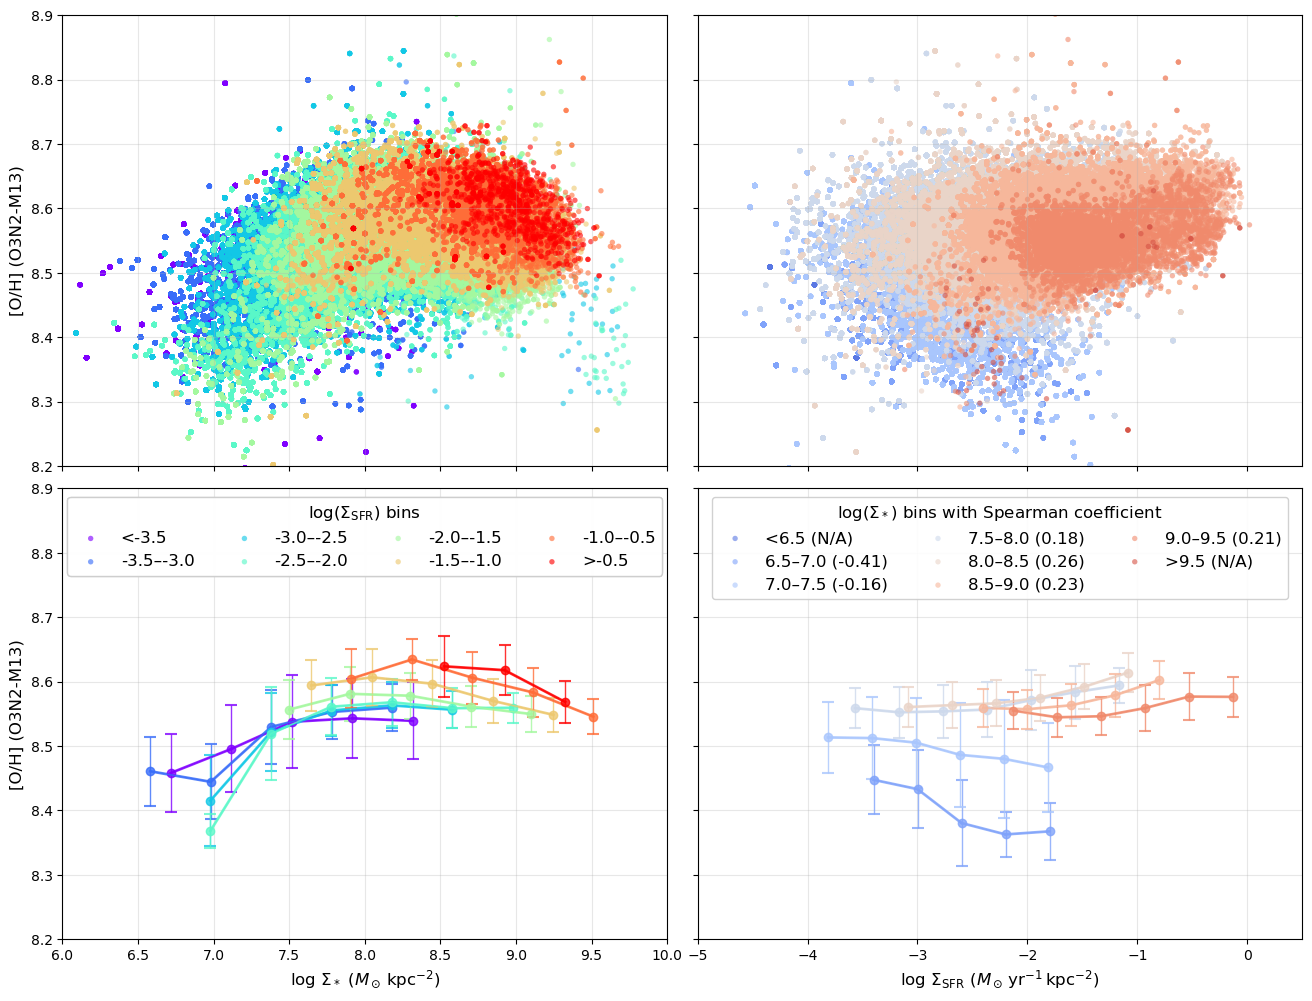


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*)$ bins with Spearman coefficient', title_fontsize=12)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII r

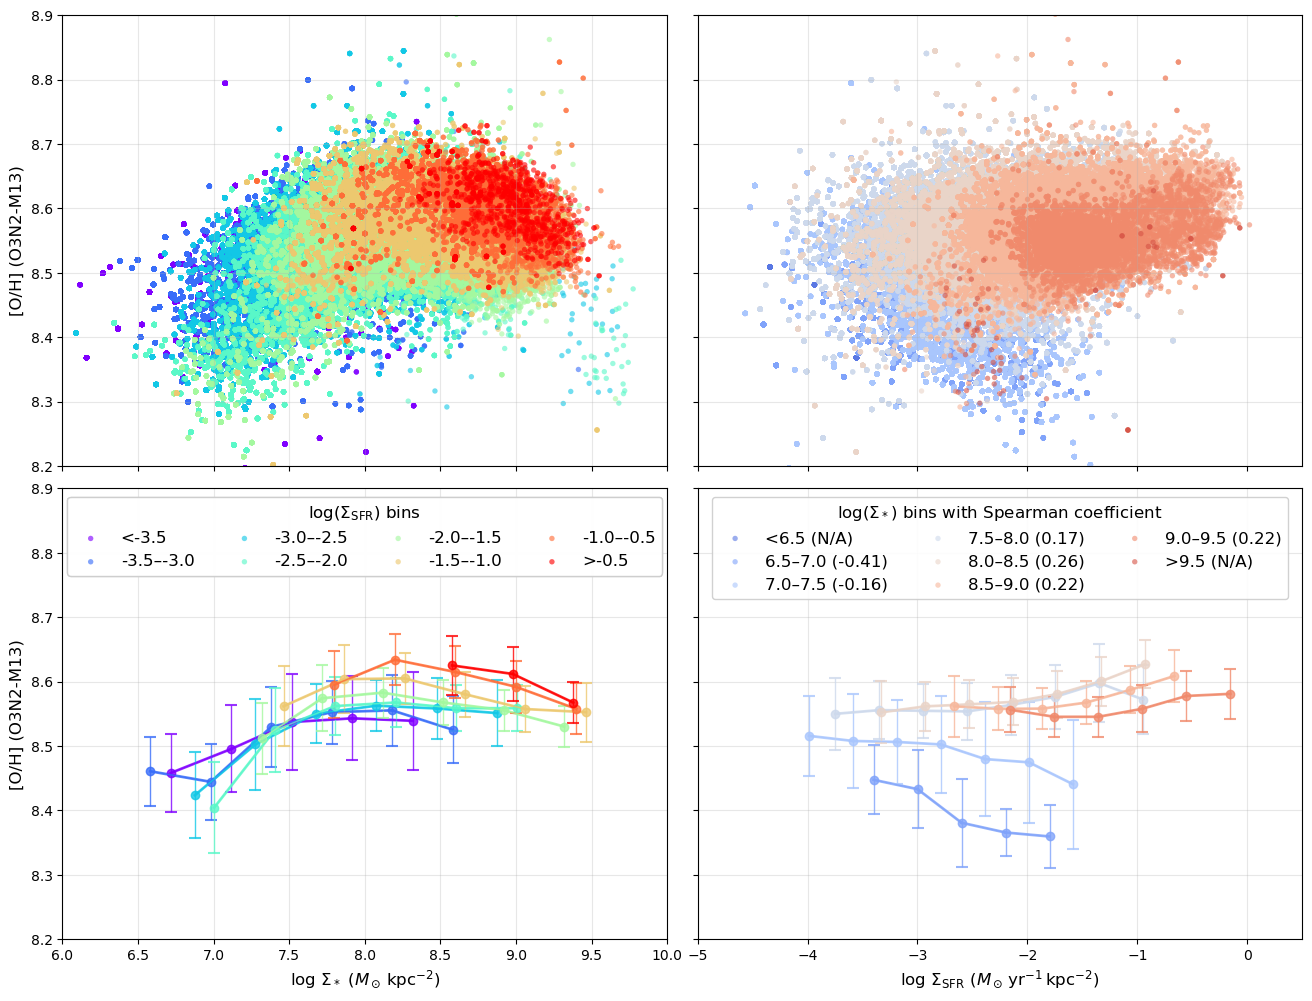


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit


def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)


def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (
        np.array(valid_centers),
        np.array(medians),
        np.array(stds),
        np.array(counts),
        np.array(valid_bin_indices),
    )


def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))


def compute_density_mask(
    x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False
):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(
        H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0
    )
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


def sigma_clip_2d(x_vals, y_vals, nsigma=3.0):
    """Simple 2D sigma-clip mask: keep points within ±nsigma in BOTH x and y."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        return np.zeros_like(x_vals, dtype=bool)

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]

    x_mean, x_std = np.nanmean(x), np.nanstd(x)
    y_mean, y_std = np.nanmean(y), np.nanstd(y)

    mask_local = np.ones_like(x, dtype=bool)
    if np.isfinite(x_std) and x_std > 0:
        mask_local &= np.abs(x - x_mean) < nsigma * x_std
    if np.isfinite(y_std) and y_std > 0:
        mask_local &= np.abs(y - y_mean) < nsigma * y_std

    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    return full_mask


def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, "Sánchez+13", ":", "olive"))
    x_bb = np.linspace(7.0, 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, "Barrera-Ballesteros+16", "--", "brown"))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, "Erroz-Ferrer+17", "-.", "pink"))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(
            x,
            y,
            label=label if show_legend else None,
            linewidth=2,
            linestyle=linestyle,
            color=color,
        )


bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("=" * 80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (
            np.isfinite(logSigmaM)
            & np.isfinite(logSigmaSFR_HII)
            & np.isfinite(oh_o3n2_m13_HII)
        )
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "=" * 80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("=" * 80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = [
    "<-3.5",
    "-3.5–-3.0",
    "-3.0–-2.5",
    "-2.5–-2.0",
    "-2.0–-1.5",
    "-1.5–-1.0",
    "-1.0–-0.5",
    ">-0.5",
]
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "=" * 80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("=" * 80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = [
    "<6.5",
    "6.5–7.0",
    "7.0–7.5",
    "7.5–8.0",
    "8.0–8.5",
    "8.5–9.0",
    "9.0–9.5",
    ">9.5",
]
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "=" * 80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("=" * 80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex="col", sharey="all")
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = "O3N2-M13"
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(
    f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}"
)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (
        all_logSigmaSFR_HII < sfr_bin_edges[i + 1]
    )
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(
            x_bin_all,
            y_bin_all,
            c=[colors_sfr[i]],
            s=15,
            alpha=0.6,
            edgecolors="none",
            rasterized=True,
        )
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])

        # Replace 95% contour selection with 3σ clipping to remove outliers
        mask_clip = sigma_clip_2d(x_bin_all, y_bin_all, nsigma=3.0)
        x_bin = x_bin_all[mask_clip]
        y_bin = y_bin_all[mask_clip]

        if len(x_bin) >= 10:
            (
                mass_centers_HII,
                medians_HII,
                stds_HII,
                counts_HII,
                valid_bin_indices_HII,
            ) = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                ax_rMZR_median.errorbar(
                    mass_centers_HII,
                    medians_HII,
                    yerr=stds_HII,
                    color=colors_sfr[i],
                    marker="o",
                    markersize=6,
                    linewidth=1,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.8,
                )
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot(
                            [mass_centers_HII[j], mass_centers_HII[j + 1]],
                            [medians_HII[j], medians_HII[j + 1]],
                            color=colors_sfr[i],
                            linewidth=2,
                            alpha=0.8,
                        )
                valid_bins_rMZR += 1

ax_rMZR_scatter.set_ylabel(f"[O/H] ({calib_name_HII})", fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(
    r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12
)
ax_rMZR_median.set_ylabel(f"[O/H] ({calib_name_HII})", fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(
    legend_handles_sfr,
    legend_labels_sfr,
    loc="upper center",
    ncol=4,
    fontsize=12,
    framealpha=0.9,
    title=r"$\log(\Sigma_\mathrm{SFR})$ bins",
    title_fontsize=12,
)
ax_rMZR_median.add_artist(legend1)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (
        all_logSigmaM_HII < sigmaM_bin_edges[i + 1]
    )
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(
            x_bin_all,
            y_bin_all,
            c=[colors_sigmaM[i]],
            s=15,
            alpha=0.6,
            edgecolors="none",
            rasterized=True,
        )
        legend_handles_sigmaM.append(scatter_hii)

        # Replace 95% contour selection with 3σ clipping to remove outliers
        mask_clip = sigma_clip_2d(x_bin_all, y_bin_all, nsigma=3.0)
        x_clipped = x_bin_all[mask_clip]
        y_clipped = y_bin_all[mask_clip]

        spearman_text = "N/A"
        if len(x_clipped) > 1:
            (
                sfr_centers_HII,
                medians_HII,
                stds_HII,
                counts_HII,
                valid_bin_indices_HII,
            ) = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                ax_Zgas_median.errorbar(
                    sfr_centers_HII,
                    medians_HII,
                    yerr=stds_HII,
                    color=colors_sigmaM[i],
                    marker="o",
                    markersize=6,
                    linewidth=1,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.8,
                )
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot(
                            [sfr_centers_HII[j], sfr_centers_HII[j + 1]],
                            [medians_HII[j], medians_HII[j + 1]],
                            color=colors_sigmaM[i],
                            linewidth=2,
                            alpha=0.8,
                        )
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(
    r"$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
    fontsize=12,
)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
ax_Zgas_median.legend(
    legend_handles_sigmaM,
    legend_labels_sigmaM_display,
    loc="upper center",
    ncol=3,
    fontsize=12,
    framealpha=0.9,
    title=r"$\log(\Sigma_*)$ bins with Spearman coefficient",
    title_fontsize=12,
)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("=" * 80)
print(
    f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies"
)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII r

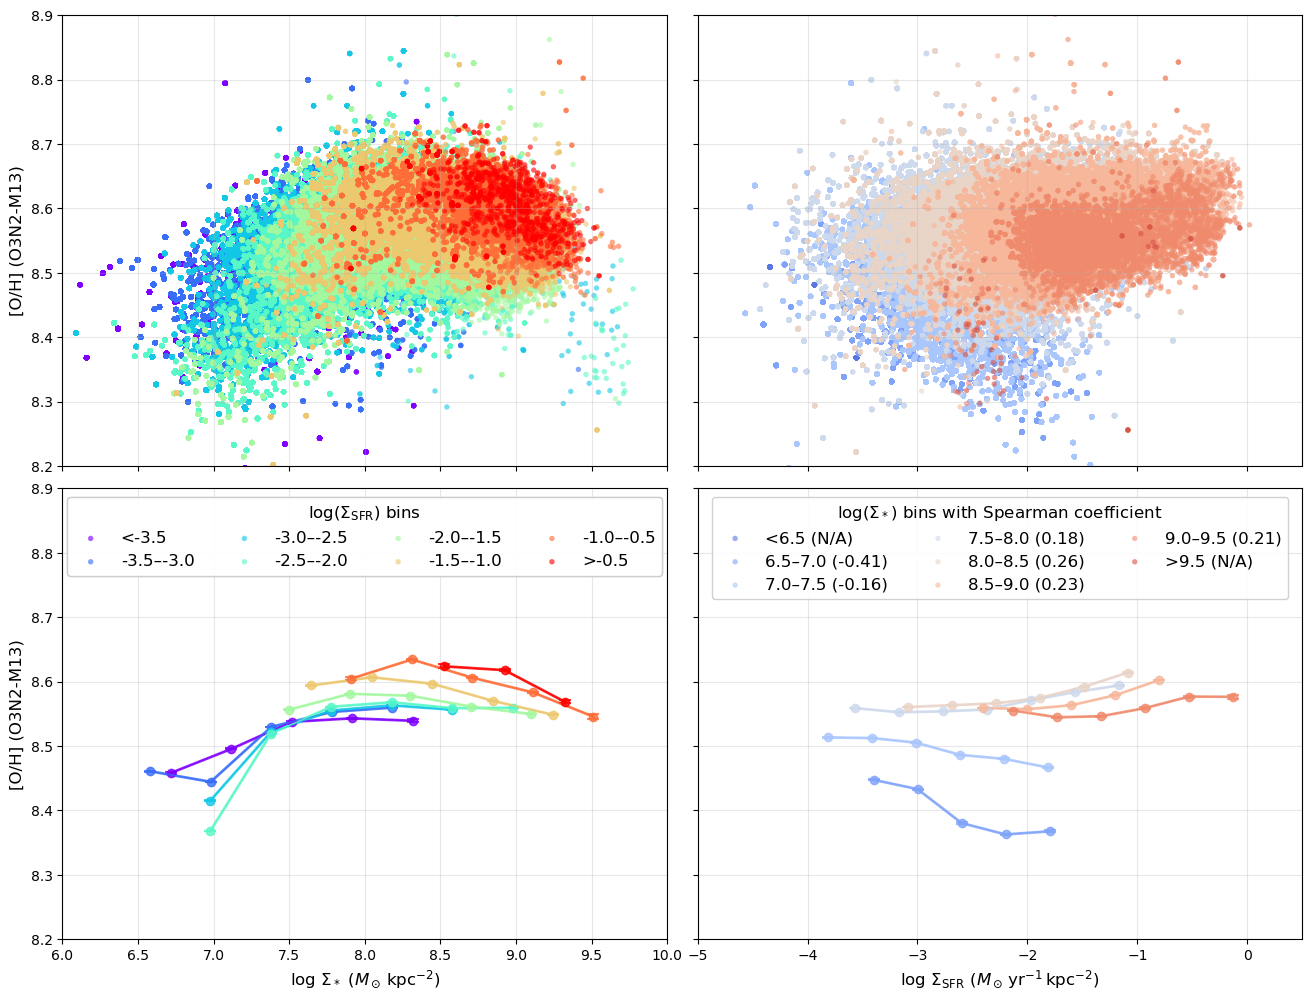


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [5]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {np.nanmedian(yerr_HII):.4f}")
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {np.nanmedian(yerr_HII):.4f}")
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*)$ bins with Spearman coefficient', title_fontsize=12)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII r

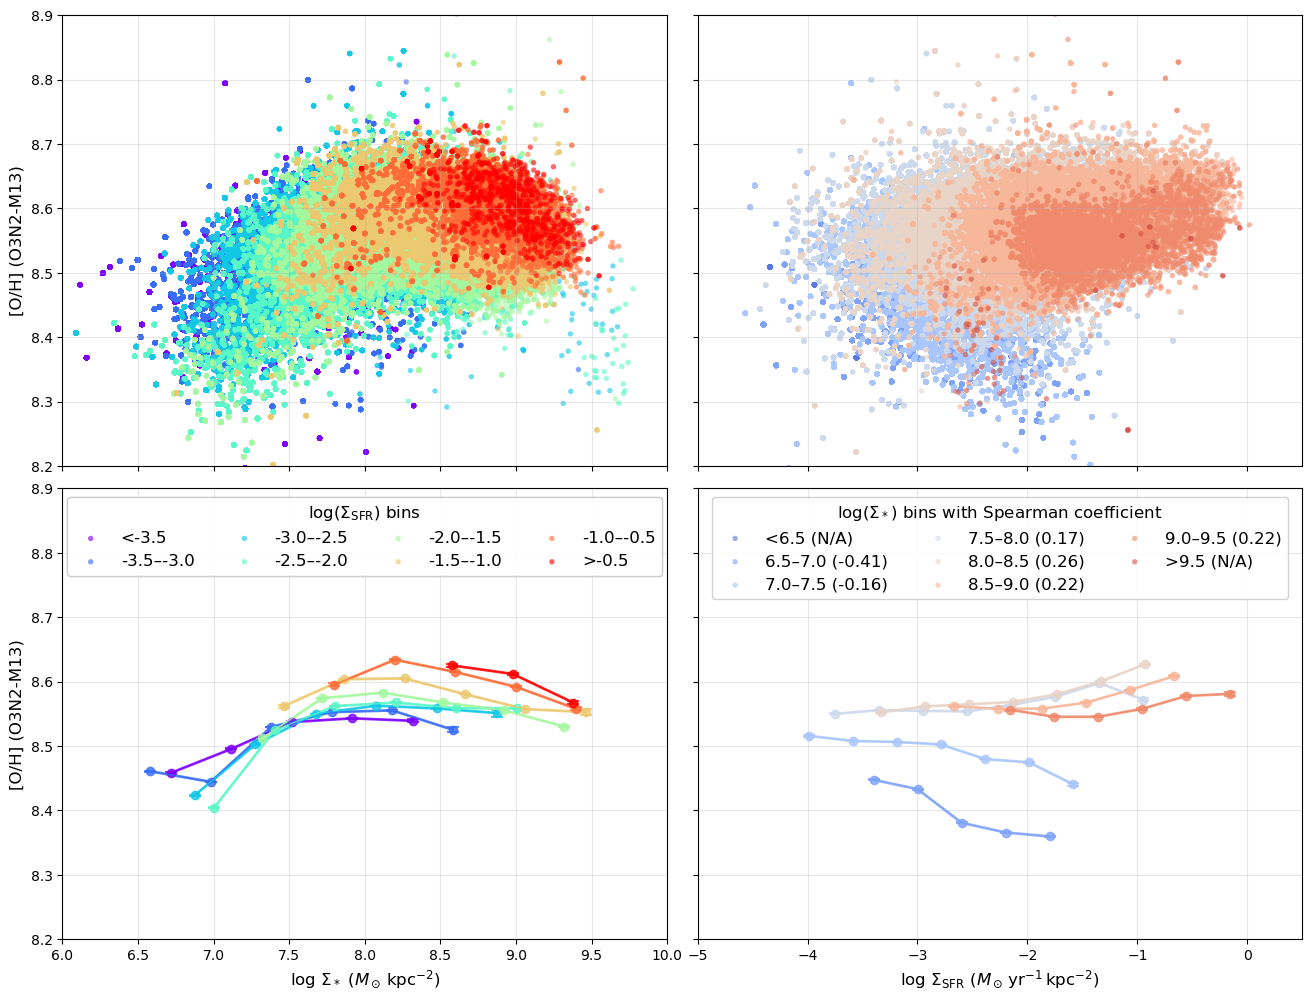


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [6]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit


def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)


def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (
        np.array(valid_centers),
        np.array(medians),
        np.array(stds),
        np.array(counts),
        np.array(valid_bin_indices),
    )


def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))


def compute_density_mask(
    x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False
):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(
        H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0
    )
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


def sigma_clip_2d(x_vals, y_vals, nsigma=3.0):
    """Simple 2D sigma-clip mask: keep points within ±nsigma in BOTH x and y."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        return np.zeros_like(x_vals, dtype=bool)

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]

    x_mean, x_std = np.nanmean(x), np.nanstd(x)
    y_mean, y_std = np.nanmean(y), np.nanstd(y)

    mask_local = np.ones_like(x, dtype=bool)
    if np.isfinite(x_std) and x_std > 0:
        mask_local &= np.abs(x - x_mean) < nsigma * x_std
    if np.isfinite(y_std) and y_std > 0:
        mask_local &= np.abs(y - y_mean) < nsigma * y_std

    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    return full_mask


def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, "Sánchez+13", ":", "olive"))
    x_bb = np.linspace(7.0, 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, "Barrera-Ballesteros+16", "--", "brown"))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, "Erroz-Ferrer+17", "-.", "pink"))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(
            x,
            y,
            label=label if show_legend else None,
            linewidth=2,
            linestyle=linestyle,
            color=color,
        )


bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("=" * 80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (
            np.isfinite(logSigmaM)
            & np.isfinite(logSigmaSFR_HII)
            & np.isfinite(oh_o3n2_m13_HII)
        )
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "=" * 80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("=" * 80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = [
    "<-3.5",
    "-3.5–-3.0",
    "-3.0–-2.5",
    "-2.5–-2.0",
    "-2.0–-1.5",
    "-1.5–-1.0",
    "-1.0–-0.5",
    ">-0.5",
]
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "=" * 80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("=" * 80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = [
    "<6.5",
    "6.5–7.0",
    "7.0–7.5",
    "7.5–8.0",
    "8.0–8.5",
    "8.5–9.0",
    "9.0–9.5",
    ">9.5",
]
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "=" * 80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("=" * 80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex="col", sharey="all")
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = "O3N2-M13"
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(
    f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}"
)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (
        all_logSigmaSFR_HII < sfr_bin_edges[i + 1]
    )
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(
            x_bin_all,
            y_bin_all,
            c=[colors_sfr[i]],
            s=15,
            alpha=0.6,
            edgecolors="none",
            rasterized=True,
        )
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])

        # Replace 95% contour selection with 3σ clipping to remove outliers
        mask_clip = sigma_clip_2d(x_bin_all, y_bin_all, nsigma=3.0)
        x_bin = x_bin_all[mask_clip]
        y_bin = y_bin_all[mask_clip]

        if len(x_bin) >= 10:
            (
                mass_centers_HII,
                medians_HII,
                stds_HII,
                counts_HII,
                valid_bin_indices_HII,
            ) = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {np.nanmedian(yerr_HII):.4f}")
                ax_rMZR_median.errorbar(
                    mass_centers_HII,
                    medians_HII,
                    yerr=yerr_HII,
                    color=colors_sfr[i],
                    marker="o",
                    markersize=6,
                    linewidth=1,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.8,
                )
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot(
                            [mass_centers_HII[j], mass_centers_HII[j + 1]],
                            [medians_HII[j], medians_HII[j + 1]],
                            color=colors_sfr[i],
                            linewidth=2,
                            alpha=0.8,
                        )
                valid_bins_rMZR += 1

ax_rMZR_scatter.set_ylabel(f"[O/H] ({calib_name_HII})", fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(
    r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12
)
ax_rMZR_median.set_ylabel(f"[O/H] ({calib_name_HII})", fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(
    legend_handles_sfr,
    legend_labels_sfr,
    loc="upper center",
    ncol=4,
    fontsize=12,
    framealpha=0.9,
    title=r"$\log(\Sigma_\mathrm{SFR})$ bins",
    title_fontsize=12,
)
ax_rMZR_median.add_artist(legend1)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (
        all_logSigmaM_HII < sigmaM_bin_edges[i + 1]
    )
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(
            x_bin_all,
            y_bin_all,
            c=[colors_sigmaM[i]],
            s=15,
            alpha=0.6,
            edgecolors="none",
            rasterized=True,
        )
        legend_handles_sigmaM.append(scatter_hii)

        # Replace 95% contour selection with 3σ clipping to remove outliers
        mask_clip = sigma_clip_2d(x_bin_all, y_bin_all, nsigma=3.0)
        x_clipped = x_bin_all[mask_clip]
        y_clipped = y_bin_all[mask_clip]

        spearman_text = "N/A"
        if len(x_clipped) > 1:
            (
                sfr_centers_HII,
                medians_HII,
                stds_HII,
                counts_HII,
                valid_bin_indices_HII,
            ) = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {np.nanmedian(yerr_HII):.4f}")
                ax_Zgas_median.errorbar(
                    sfr_centers_HII,
                    medians_HII,
                    yerr=yerr_HII,
                    color=colors_sigmaM[i],
                    marker="o",
                    markersize=6,
                    linewidth=1,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.8,
                )
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot(
                            [sfr_centers_HII[j], sfr_centers_HII[j + 1]],
                            [medians_HII[j], medians_HII[j + 1]],
                            color=colors_sigmaM[i],
                            linewidth=2,
                            alpha=0.8,
                        )
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(
    r"$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
    fontsize=12,
)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
ax_Zgas_median.legend(
    legend_handles_sigmaM,
    legend_labels_sigmaM_display,
    loc="upper center",
    ncol=3,
    fontsize=12,
    framealpha=0.9,
    title=r"$\log(\Sigma_*)$ bins with Spearman coefficient",
    title_fontsize=12,
)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("=" * 80)
print(
    f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies"
)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
